In [1]:
from pulp import *
import matplotlib.pyplot as plt
import numpy as np

## Questão 1: 

- a) Para começar eu fiz um gerador de pontos que consiste de uma reta acrescido de um erro, que vem de uma normal padrão. Fiz uma primeira visualização para termos ideia do que estamos trabalhando sobre com a reta sem os erros.

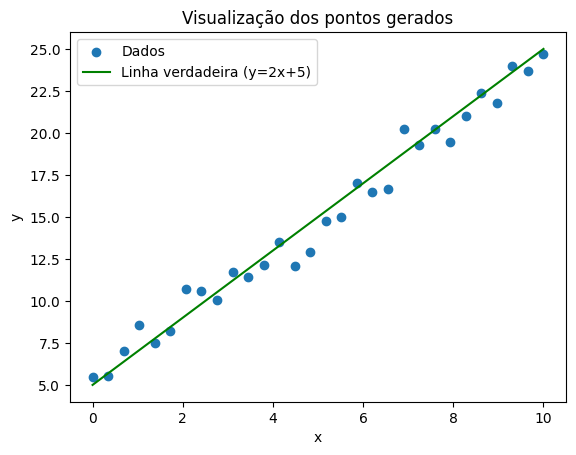

In [2]:
def gerar_pontos(a=2, b=5, n=30, erro_std=1.0, seed=42):
    np.random.seed(seed)
    x = np.linspace(0, 10, n)
    erro = np.random.normal(0, erro_std, n)
    y = a * x + b + erro
    return x, y

x, y = gerar_pontos()

plt.scatter(x, y, label='Dados')
plt.plot(x, 2*x+5, color='green', label='Linha verdadeira (y=2x+5)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Visualização dos pontos gerados')
plt.legend()
plt.show()

Agora farei o ajuste que tem uma delicadeza: Por termos que trabalhar sobre operações lineares, não podemos fazer a operação de módulo (costumeiramente usada para o cálculo das distancias) então temos que fazer uma restrição com os 2 casos do módulo de forma a compensar este problema. Mas em seguida, temos uma visualização com a reta ajustada em vermelho.

O termo independente é 4.8788607
O coeficiente linear é 1.9503376
O valor do resíduo quadrático é  20.033108481


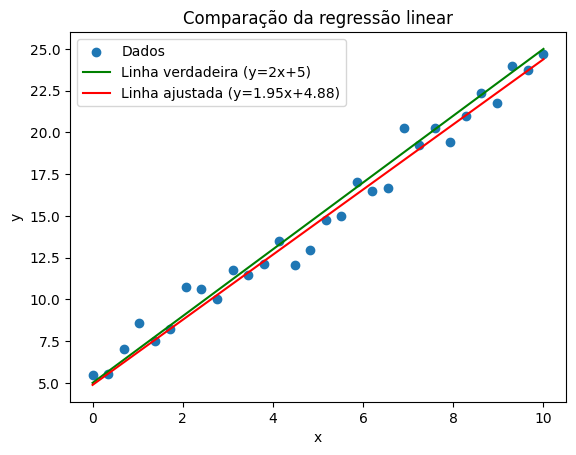

In [3]:
LR = LpProblem("RL", LpMinimize)

# Definindo as variáveis de regressão
a1 = LpVariable("a1", cat='Continuous')
a0 = LpVariable("a0", cat='Continuous')

# Variáveis auxiliares para conseguir linearizar o problema
Z = LpVariable.dicts("Z", range(len(x)), cat='Continuous')

# Adiciona as restrições para modelar o valor absoluto
for i in range(len(x)):
    LR += a1*x[i] + a0 - y[i] <= Z[i]
    LR += -(a1*x[i] + a0 - y[i]) <= Z[i]

# Função objetivo
LR += lpSum(Z[i] for i in range(len(x)))

LR.solve()

for var in LR.variables():
    if  var.name == "a0":
        print(f"O termo independente é {var.value()}")
    if  var.name == "a1":
        print(f"O coeficiente linear é {var.value()}")

print("O valor do resíduo quadrático é ", LR.objective.value())

#plotar a visualização do ajuste
plt.scatter(x, y, label='Dados')
plt.plot(x, 2*x+5, color='green', label='Linha verdadeira (y=2x+5)')
plt.plot(x, a1.value()*x + a0.value(), color='red', label='Linha ajustada (y={:.2f}x+{:.2f})'.format(a1.value(), a0.value()))
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.show()


Apesar do bom resultado,a fim de testes, optei por testar trocar a quantidade de pontos de 30 para 50 para avaliar se o ajuste se aproximaria mais do real.

O termo independente é 4.8672153
O coeficiente linear é 1.9731498
O valor do resíduo quadrático é  36.65046258700001


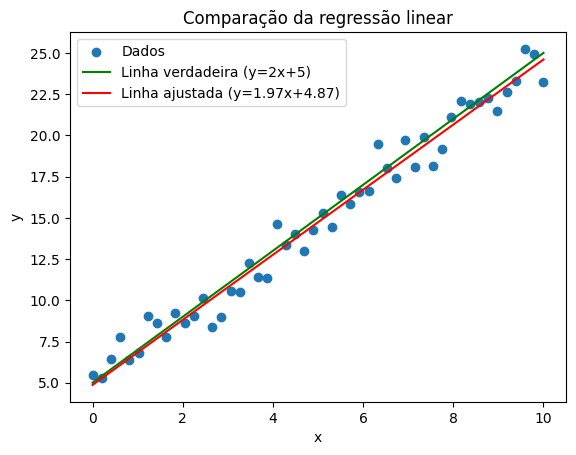

In [4]:
def gerar_pontos2(a=2, b=5, n=50, erro_std=1.0, seed=42):
    np.random.seed(seed)
    x = np.linspace(0, 10, n)
    erro = np.random.normal(0, erro_std, n)
    y = a * x + b + erro
    return x, y

x2, y2 = gerar_pontos2()

LR2 = LpProblem("RL2", LpMinimize)

# Definindo as variáveis de regressão
a1_2 = LpVariable("a1_2", cat='Continuous')
a0_2 = LpVariable("a0_2", cat='Continuous')

# Variáveis auxiliares para conseguir linearizar o problema
Z = LpVariable.dicts("Z", range(len(x2)), cat='Continuous')

# Adiciona as restrições para modelar o valor absoluto
for i in range(len(x2)):
    LR2 += a1_2*x2[i] + a0_2 - y2[i] <= Z[i]
    LR2 += -(a1_2*x2[i] + a0_2 - y2[i]) <= Z[i]

# Função objetivo
LR2 += lpSum(Z[i] for i in range(len(x2)))

LR2.solve()

for var in LR2.variables():
    if  var.name == "a0_2":
        print(f"O termo independente é {var.value()}")
    if  var.name == "a1_2":
        print(f"O coeficiente linear é {var.value()}")

print("O valor do resíduo quadrático é ", LR2.objective.value())

#plotar a visualização do ajuste
plt.scatter(x2, y2, label='Dados')
plt.plot(x2, 2*x2+5, color='green', label='Linha verdadeira (y=2x+5)')
plt.plot(x2, a1_2.value()*x2 + a0_2.value(), color='red', label='Linha ajustada (y={:.2f}x+{:.2f})'.format(a1_2.value(), a0_2.value()))
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.show()

Agora fazendo uma análise mais direta entre os 2 resultados: (O primeiro resultado será do primeiro ajuste)

In [5]:
print(f"os valores de termo independente são: {a0.value(), a0_2.value()}")
print(f"os valores de coeficiente linear são: {a1.value(), a1_2.value()}")
print(f"os valores de resíduos quadráticos são: {LR.objective.value(), LR2.objective.value()}")

os valores de termo independente são: (4.8788607, 4.8672153)
os valores de coeficiente linear são: (1.9503376, 1.9731498)
os valores de resíduos quadráticos são: (20.033108481, 36.65046258700001)


Apesar de parecerem próximos há uma sutileza interessante: Os coeficientes lineares apesar de muito próximos, o do segundo resultado está quase na metade do intervalo entre o primeiro resultado e o real, ou seja, o erro foi diminuído pela metade. E apesar do erro no termo independente ter aumentado, o segundo ajuste pelo coeficiente lienar se mostra consideravelmente superior pois quanto maior fosse o intervalo de X associado, mais próximo estaria do real quando comparado ao primeiro ajuste. E os resíduos quadráticos não podem ser comparados diretamente pois estamos somando quantidades de pontos diferentes, e caso dividido pelo número de pontos de cada para uma estimativa, teríamos resultados próximos que poderiam ser facilmente explicáveis pelos erros.

- b) Agora refarei o passo a passo feito do item anterior, mas usando o máximo do modulo.

O termo independente é 4.9100276
O coeficiente linear é 1.976476
O valor do resíduo quadrático é  1.7178555


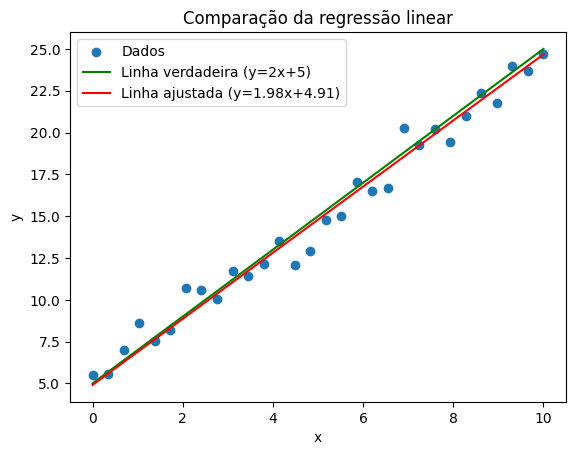

In [6]:
LR = LpProblem("RL", LpMinimize)

# Definindo as variáveis 
a1 = LpVariable("a1", cat='Continuous')
a0 = LpVariable("a0", cat='Continuous')

# Variáveis auxiliares para os valores absolutos
Z = LpVariable.dicts("Z", range(len(x)), cat='Continuous')

# Adiciona as restrições para modelar o valor absoluto
for i in range(len(x)):
    LR += a1*x[i] + a0 - y[i] <= Z[i]
    LR += -(a1*x[i] + a0 - y[i]) <= Z[i]

# Função objetivo: Aqui temos a diferença entre minimizar a soma dos resíduos e minimizar o maior resíduo
M = LpVariable("M", cat='Continuous')
for i in range(len(x)):
    LR += Z[i] <= M
LR += M

LR.solve()

for var in LR.variables():
    if  var.name == "a0":
        print(f"O termo independente é {var.value()}")
    if  var.name == "a1":
        print(f"O coeficiente linear é {var.value()}")

print("O valor do resíduo quadrático é ", LR.objective.value())

#plotar a visualização do ajuste
plt.scatter(x, y, label='Dados')
plt.plot(x, 2*x+5, color='green', label='Linha verdadeira (y=2x+5)')
plt.plot(x, a1.value()*x + a0.value(), color='red', label='Linha ajustada (y={:.2f}x+{:.2f})'.format(a1.value(), a0.value()))
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.show()

De cara parece que obtivemos um resultado melhor que no item _a_, mas farei o teste com mais pontos.

O termo independente é 5.012023
O coeficiente linear é 1.9905287
O valor do resíduo quadrático é  1.9001754


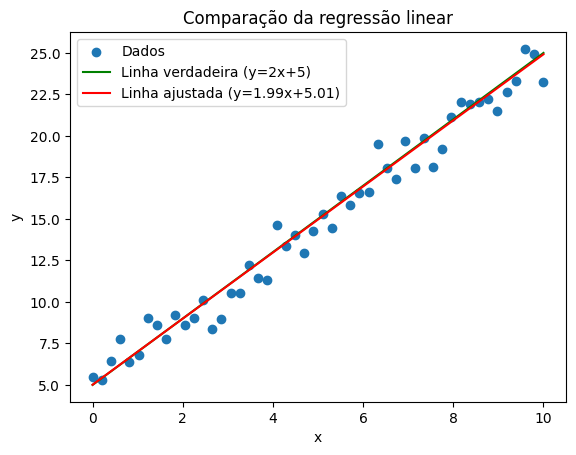

In [7]:
x2, y2 = gerar_pontos2()

LR2 = LpProblem("RL", LpMinimize)

# Definindo as variáveis 
a1_2 = LpVariable("a1_2", cat='Continuous')
a0_2 = LpVariable("a0_2", cat='Continuous')

# Variáveis auxiliares para os valores absolutos
Z = LpVariable.dicts("Z", range(len(x2)), cat='Continuous')

# Adiciona as restrições para modelar o valor absoluto
for i in range(len(x2)):
    LR2 += a1_2*x2[i] + a0_2 - y2[i] <= Z[i]
    LR2 += -(a1_2*x2[i] + a0_2 - y2[i]) <= Z[i]

# Função objetivo
M = LpVariable("M", cat='Continuous')
for i in range(len(x2)):
    LR2 += Z[i] <= M
LR2 += M

LR2.solve()

for var in LR2.variables():
    if  var.name == "a0_2":
        print(f"O termo independente é {var.value()}")
    if  var.name == "a1_2":
        print(f"O coeficiente linear é {var.value()}")

print("O valor do resíduo quadrático é ", LR2.objective.value())

#plotar a visualização do ajuste
plt.scatter(x2, y2, label='Dados')
plt.plot(x2, 2*x2+5, color='green', label='Linha verdadeira (y=2x+5)')
plt.plot(x2, a1_2.value()*x2 + a0_2.value(), color='red', label='Linha ajustada (y={:.2f}x+{:.2f})'.format(a1_2.value(), a0_2.value()))
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.show()

De cara vemos que os resultados foram ainda melhores que no primeiro teste, mas a fim de escancar as diferenças farei o mesmo que no item *a*

In [8]:
print(f"os valores de termo independente são: {a0.value(), a0_2.value()}")
print(f"os valores de coeficiente linear são: {a1.value(), a1_2.value()}")
print(f"os valores de resíduos quadráticos são: {LR.objective.value(), LR2.objective.value()}")

os valores de termo independente são: (4.9100276, 5.012023)
os valores de coeficiente linear são: (1.976476, 1.9905287)
os valores de resíduos quadráticos são: (1.7178555, 1.9001754)


De fato temos que os resultados no segundo ajuste foram muito melhores quando comparados com os do primeiro ajuste. Um comentário curioso a se fazer é que apesar de aqui os valores objetivo das funções não estarem diretamente associados ao número de pontos, ao ter mais pontos eu passo a poder ter maiores outliers devido ao erro, o que torna o fato do erro no segundo ajuste maior completamente plausível.

c) vou aplicar um polinomio de grau 3 e K para testes:

Primeiro irei fazer minimizando o somatório dos resíduos e em seguida minimizando o resíduo máximo.

Mas antes dos testes, optei por algumas mudanças para melhorar a visualização: (mudanças essas feitas empiricamente nesta ordem)
- mudei a escala do gráfico e pontos para melhor visualição da maior dimensão do polinomio feito.
- mudança na função base para que o gráfico não ficasse distorcido verticalmente e no erro para acompanhar as novas escalas.
- Por serem poucas dimensões, as implementei manualmente. 


O termo independente é 9.6496526
O coeficiente linear é 0.82455056
O coeficiente quadrático é 0.020719787
O coeficiente cúbico é -0.00027079668
O valor do resíduo quadrático é  349.80384586600013


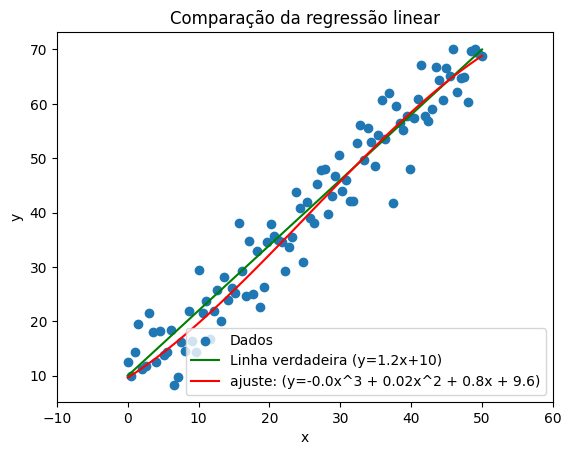

In [9]:
def gerar_pontos(a=1.2, b=10, n=100, erro_std=5, seed=42):
    np.random.seed(seed)
    x = np.linspace(0, 50, n)
    erro = np.random.normal(0, erro_std, n)
    y = a * x + b + erro
    return x, y

x, y = gerar_pontos()


LR = LpProblem("RL", LpMinimize)

# Definindo as variáveis de regressão
a3 = LpVariable("a3", cat='Continuous')
a2 = LpVariable("a2", cat='Continuous')
a1 = LpVariable("a1", cat='Continuous')
a0 = LpVariable("a0", cat='Continuous')

# Variáveis auxiliares para conseguir linearizar o problema
Z = LpVariable.dicts("Z", range(len(x)), cat='Continuous')

# Adiciona as restrições para modelar o valor absoluto
for i in range(len(x)):
    LR += a3*x[i]**3 + a2*x[i]**2 + a1*x[i] + a0 - y[i] <= Z[i]
    LR += -(a3*x[i]**3 + a2*x[i]**2 + a1*x[i] + a0 - y[i]) <= Z[i]

# Função objetivo
LR += lpSum(Z[i] for i in range(len(x)))

LR.solve()

for var in LR.variables():
    if  var.name == "a0":
        print(f"O termo independente é {var.value()}")
    if  var.name == "a1":
        print(f"O coeficiente linear é {var.value()}")
    if  var.name == "a2":
        print(f"O coeficiente quadrático é {var.value()}")
    if  var.name == "a3":
        print(f"O coeficiente cúbico é {var.value()}")

print("O valor do resíduo quadrático é ", LR.objective.value())

#plotar a visualização do ajuste
plt.scatter(x, y, label='Dados')
plt.plot(x, 1.2*x+10, color='green', label='Linha verdadeira (y=1.2x+10)')
plt.plot(x, a3.value()*x**3 + a2.value()*x**2 + a1.value()*x + a0.value(), color='red', label='ajuste: (y={:.1f}x^3 + {:.2f}x^2 + {:.1f}x + {:.1f})'.format(a3.value(), a2.value(), a1.value(), a0.value()))
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.xlim(-10, 60)
plt.show()


O valor do resíduo quadrático é  206.53442762000003


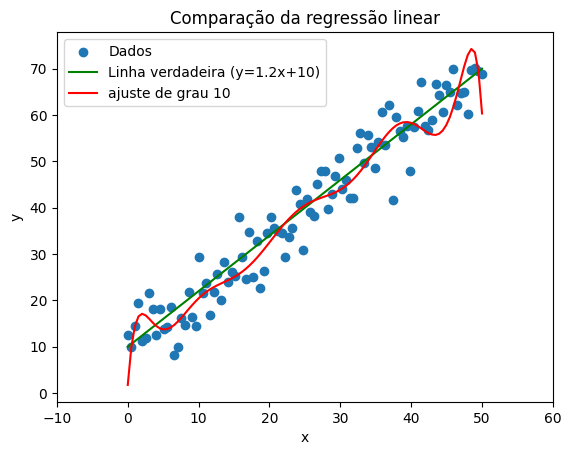

In [10]:
LR2 = LpProblem("RL2", LpMinimize)

#este K é o grau do polinômio que pode ser mudado como quiser.
k = 10 #tenho que usar k+1 nas variáveis para considerar o termo independente

# Definindo as variáveis de regressão
coef = LpVariable.dicts("a", range(k+1), cat='Continuous')

# Variáveis auxiliares para conseguir linearizar o problema
Z = LpVariable.dicts("Z", range(len(x)), cat='Continuous')

# Adiciona as restrições para modelar o valor absoluto
for i in range(len(x)):
    LR2 += lpSum(coef[j] * x[i]**j for j in range(k+1)) - y[i] <= Z[i]
    LR2 += -(lpSum(coef[j] * x[i]**j for j in range(k+1)) - y[i]) <= Z[i]

# Função objetivo
LR2 += lpSum(Z[i] for i in range(len(x)))

LR2.solve()

#caso queira ver os coeficientes tire as próximas 3 linhas de comentário
# for var in LR2.variables():
#     if  var.name.startswith("a"):
#         print(f"O coeficiente {var.name} é {var.value()}")

print("O valor do resíduo quadrático é ", LR2.objective.value())

#plotar a visualização do ajuste
plt.scatter(x, y, label='Dados')
plt.plot(x, 1.2*x+10, color='green', label='Linha verdadeira (y=1.2x+10)')
y_fit = sum(coef[j].value() * x**j for j in range(k+1))
plt.plot(x, y_fit, color='red', label='ajuste de grau 10')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.xlim(-10, 60)
plt.show()

Vou plotar as 2 funções juntas para comparação: Mudei a cor do ajuste cúbico para preto.

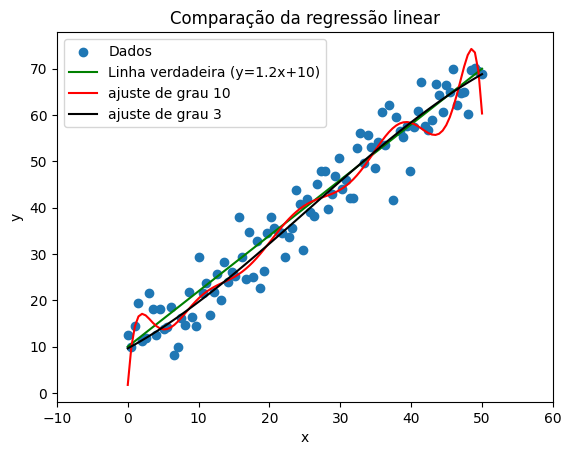

In [11]:
plt.scatter(x, y, label='Dados')
plt.plot(x, 1.2*x+10, color='green', label='Linha verdadeira (y=1.2x+10)')
y_fit = sum(coef[j].value() * x**j for j in range(k+1))
plt.plot(x, y_fit, color='red', label='ajuste de grau 10')
plt.plot(x, a3.value()*x**3 + a2.value()*x**2 + a1.value()*x + a0.value(), color='black', label='ajuste de grau 3')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.xlim(-10, 60)
plt.show()

Visivelmente o gráfico em vermelho está fazendo um *overfitting*, então farei um novo conjunto de dados usando a mesma função base (só vou mudar a seed que influencia o erro e as escalas de pontos) e vou conferir os valores das funções objetivos

Os resultados foram : 457.47 e 519.16 para o somatório de resíduos 


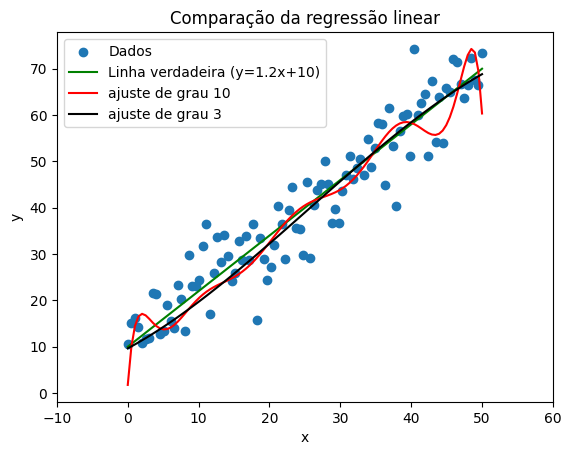

In [12]:
def gerar_pontos(a=1.2, b=10, n=100, erro_std=5, seed=142):
    np.random.seed(seed)
    x = np.linspace(0, 50, n)
    erro = np.random.normal(0, erro_std, n)
    y = a * x + b + erro
    return x, y

x, y = gerar_pontos()

R1 = np.sum(np.abs(y - (a3.value()*x**3 + a2.value()*x**2 + a1.value()*x + a0.value())))
R2 = np.sum(np.abs(y - y_fit))

print(f"Os resultados foram : {R1:.2f} e {R2:.2f} para o somatório de resíduos ")

plt.scatter(x, y, label='Dados')
plt.plot(x, 1.2*x+10, color='green', label='Linha verdadeira (y=1.2x+10)')
# Calculate the fitted polynomial using the solved coefficients
y_fit = sum(coef[j].value() * x**j for j in range(k+1))
plt.plot(x, y_fit, color='red', label='ajuste de grau 10')
plt.plot(x, a3.value()*x**3 + a2.value()*x**2 + a1.value()*x + a0.value(), color='black', label='ajuste de grau 3')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.xlim(-10, 60)
plt.show()

Como para o conjunto de dados teste a regressao para polinomio de grau 3 teve um somatorio em modulo das diferenças do valor real para a estimativa do que o polinomio de grau 9, parece razoável admitirmos que de fato houve *overfitting*.

Agora farei o mesmo que fiz antes mas minimizando o resíduo máximo.

Começarei fazendo uma regressão de grau 3 e depois de grau k (assim como antes)

O termo independente é 6.2081725
O coeficiente linear é 1.8936141
O coeficiente quadrático é -0.031163996
O coeficiente cúbico é 0.00035871629
O valor do resíduo quadrático é  10.426341


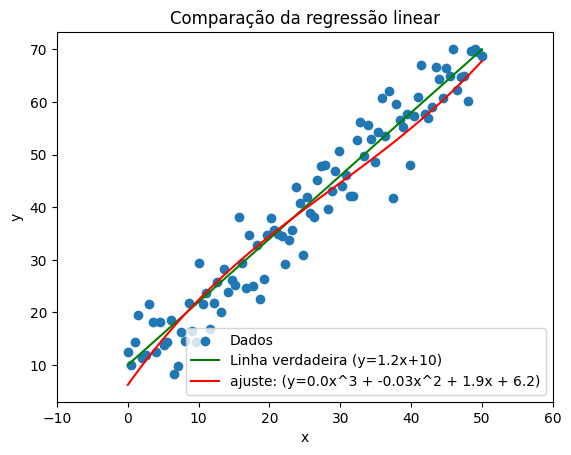

In [13]:
def gerar_pontos(a=1.2, b=10, n=100, erro_std=5, seed=42):
    np.random.seed(seed)
    x = np.linspace(0, 50, n)
    erro = np.random.normal(0, erro_std, n)
    y = a * x + b + erro
    return x, y

x, y = gerar_pontos()


LR = LpProblem("RL", LpMinimize)

# Definindo as variáveis de regressão
a3 = LpVariable("a3", cat='Continuous')
a2 = LpVariable("a2", cat='Continuous')
a1 = LpVariable("a1", cat='Continuous')
a0 = LpVariable("a0", cat='Continuous')

# Variáveis auxiliares para conseguir linearizar o problema
Z = LpVariable.dicts("Z", range(len(x)), cat='Continuous')

# Adiciona as restrições para modelar o valor absoluto
for i in range(len(x)):
    LR += a3*x[i]**3 + a2*x[i]**2 + a1*x[i] + a0 - y[i] <= Z[i]
    LR += -(a3*x[i]**3 + a2*x[i]**2 + a1*x[i] + a0 - y[i]) <= Z[i]

# Função objetivo: Aqui temos a diferença entre minimizar a soma dos resíduos e minimizar o maior resíduo
M = LpVariable("M", cat='Continuous')
for i in range(len(x)):
    LR += Z[i] <= M
LR += M


LR.solve()

for var in LR.variables():
    if  var.name == "a0":
        print(f"O termo independente é {var.value()}")
    if  var.name == "a1":
        print(f"O coeficiente linear é {var.value()}")
    if  var.name == "a2":
        print(f"O coeficiente quadrático é {var.value()}")
    if  var.name == "a3":
        print(f"O coeficiente cúbico é {var.value()}")

print("O valor do resíduo quadrático é ", LR.objective.value())

#plotar a visualização do ajuste
plt.scatter(x, y, label='Dados')
plt.plot(x, 1.2*x+10, color='green', label='Linha verdadeira (y=1.2x+10)')
plt.plot(x, a3.value()*x**3 + a2.value()*x**2 + a1.value()*x + a0.value(), color='red', label='ajuste: (y={:.1f}x^3 + {:.2f}x^2 + {:.1f}x + {:.1f})'.format(a3.value(), a2.value(), a1.value(), a0.value()))
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.xlim(-10, 60)
plt.show()


O valor do resíduo quadrático é  8.0815188


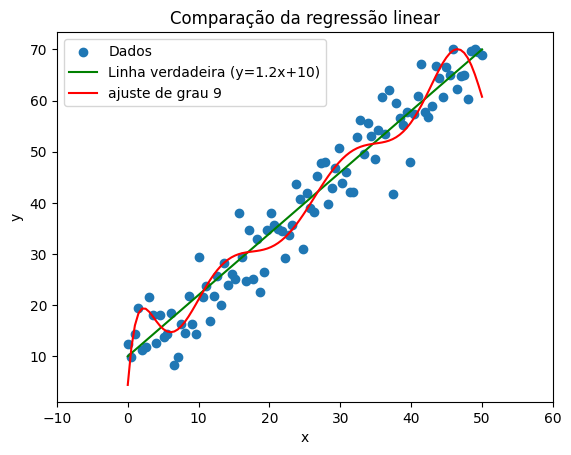

In [14]:
LR2 = LpProblem("RL2", LpMinimize)

#este K é o grau do polinômio que pode ser mudado como quiser.
k = 9 #tenho que usar k+1 nas variáveis para considerar o termo independente

# Definindo as variáveis de regressão
coef = LpVariable.dicts("a", range(k+1), cat='Continuous')

# Variáveis auxiliares para conseguir linearizar o problema
Z = LpVariable.dicts("Z", range(len(x)), cat='Continuous')

# Adiciona as restrições para modelar o valor absoluto
for i in range(len(x)):
    LR2 += lpSum(coef[j] * x[i]**j for j in range(k+1)) - y[i] <= Z[i]
    LR2 += -(lpSum(coef[j] * x[i]**j for j in range(k+1)) - y[i]) <= Z[i]

# Função objetivo
M = LpVariable("M", cat='Continuous')
for i in range(len(x)):
    LR2 += Z[i] <= M
LR2 += M

LR2.solve()

#caso queira ver os coeficientes tire as próximas 3 linhas de comentário
# for var in LR2.variables():
#     if  var.name.startswith("a"):
#         print(f"O coeficiente {var.name} é {var.value()}")

print("O valor do resíduo quadrático é ", LR2.objective.value())

#plotar a visualização do ajuste
plt.scatter(x, y, label='Dados')
plt.plot(x, 1.2*x+10, color='green', label='Linha verdadeira (y=1.2x+10)')
y_fit = sum(coef[j].value() * x**j for j in range(k+1))
plt.plot(x, y_fit, color='red', label='ajuste de grau 9')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.xlim(-10, 60)
plt.show()

Novamente parece termos tido o problema anterior de *overfitting*, então vou criar um novo conjunto de dados e ver o erro.

Os resultados foram : 18.67 e 17.58 para o maior resíduo 


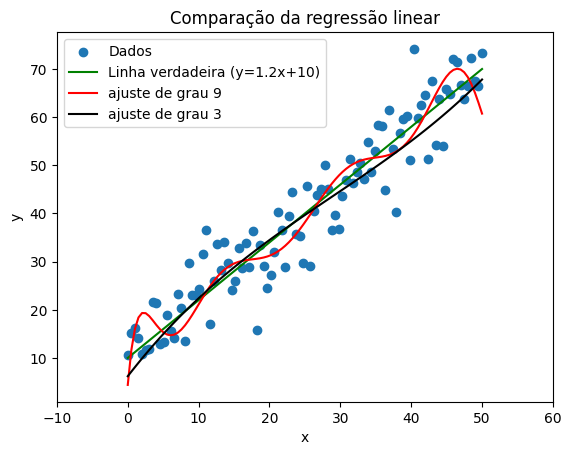

o ponto mais distante do ajuste cúbico tem posição = 40.40404040404041 74.16961892577348
o ponto mais distante do ajuste com grau k tem posição = 40.40404040404041 74.16961892577348


In [15]:
def gerar_pontos(a=1.2, b=10, n=100, erro_std=5, seed=142):
    np.random.seed(seed)
    x = np.linspace(0, 50, n)
    erro = np.random.normal(0, erro_std, n)
    y = a * x + b + erro
    return x, y

x, y = gerar_pontos()

# R1 = np.sum(np.abs(y - (a3.value()*x**3 + a2.value()*x**2 + a1.value()*x + a0.value())))
# R2 = np.sum(np.abs(y - y_fit))

R1 = 0
R2 = 0

x_sup1 = 0
y_sup1 = 0
x_sup2 = 0
y_sup2 = 0

for i in range(len(x)):
    if np.abs(y[i] - (a3.value()*x[i]**3 + a2.value()*x[i]**2 + a1.value()*x[i] + a0.value())) > R1:
        R1 = np.abs(y[i] - (a3.value()*x[i]**3 + a2.value()*x[i]**2 + a1.value()*x[i] + a0.value()))
        x_sup1 = x[i]
        y_sup1 = y[i]
    if np.abs(y[i] - y_fit[i]) > R2:
        R2 = np.abs(y[i] - y_fit[i])
        x_sup2 = x[i]
        y_sup2 = y[i]

print(f"Os resultados foram : {R1:.2f} e {R2:.2f} para o maior resíduo ")

# print(f"Os resultados foram : {R1:.2f} e {R2:.2f} para o somatório de resíduos ")

plt.scatter(x, y, label='Dados')
plt.plot(x, 1.2*x+10, color='green', label='Linha verdadeira (y=1.2x+10)')
# Calculate the fitted polynomial using the solved coefficients
y_fit = sum(coef[j].value() * x**j for j in range(k+1))
plt.plot(x, y_fit, color='red', label='ajuste de grau 9')
plt.plot(x, a3.value()*x**3 + a2.value()*x**2 + a1.value()*x + a0.value(), color='black', label='ajuste de grau 3')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.xlim(-10, 60)
plt.show()
print("o ponto mais distante do ajuste cúbico tem posição =", x_sup1, y_sup1)
print("o ponto mais distante do ajuste com grau k tem posição =", x_sup2, y_sup2)

Ao contrário do que esperava-se, o resultado do ajuste de grau 9 foi teve resultado melhor, e após a visualização está indicado o ponto que está mais distante de cada ajuste.

- d) basicamente repetirei os algoritmos de regressao linear mas com os novos dados de entrada. Farei ambos algoritmos (minimizar o somatório de resíduos e minizar o resíduo máximo) de regressão para polinomios de 3 dimensões.

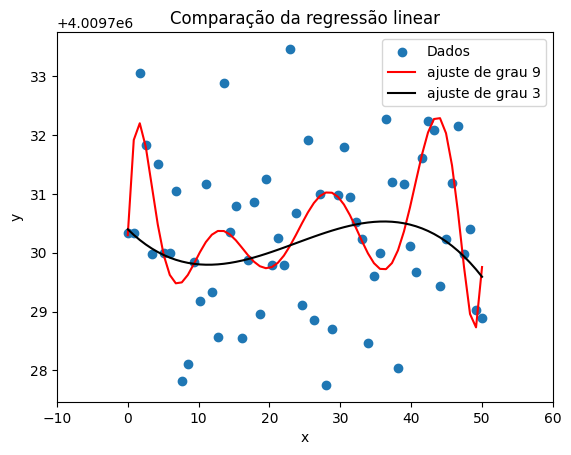

Os resultados foram : 18.67 e 17.58 para o somatório de resíduos 
Valor objetivo do ajuste grau 3: 61.33
Valor objetivo do ajuste grau 9: 44.71


In [16]:
D = 3  # Grau do polinômio que gera os dados

def gerar_pontosk(D, n=30, erro_std=1, seed=42):
    np.random.seed(seed)
    x = np.linspace(0, 50, 2*n)
    coef = np.random.uniform(-10, 10, D+1)
    erro = np.random.normal(0, erro_std*D/2, 2*n)
    y = np.sum([coef[i]*x**i for i in range(D+1)]) + erro
    return x, y, coef

x,y,coefi = gerar_pontosk(D)

LR = LpProblem("RL", LpMinimize)

# Definindo as variáveis de regressão
a3 = LpVariable("a3", cat='Continuous')
a2 = LpVariable("a2", cat='Continuous')
a1 = LpVariable("a1", cat='Continuous')
a0 = LpVariable("a0", cat='Continuous')

# Variáveis auxiliares para conseguir linearizar o problema
Z = LpVariable.dicts("Z", range(len(x)), cat='Continuous')

# Adiciona as restrições para modelar o valor absoluto
for i in range(len(x)):
    LR += a3*x[i]**3 + a2*x[i]**2 + a1*x[i] + a0 - y[i] <= Z[i]
    LR += -(a3*x[i]**3 + a2*x[i]**2 + a1*x[i] + a0 - y[i]) <= Z[i]

# Função objetivo
LR += lpSum(Z[i] for i in range(len(x)))

LR.solve()

a3_s = LR.variablesDict()["a3"].value()
a2_s = LR.variablesDict()["a2"].value()
a1_s = LR.variablesDict()["a1"].value()
a0_s = LR.variablesDict()["a0"].value()
coef_1 = [a0_s, a1_s, a2_s, a3_s]

k = 10

# Inicializa o problema LR2 antes de adicionar restrições e objetivo
LR2 = LpProblem("RL2", LpMinimize)

# Definindo as variáveis de regressão
coef = LpVariable.dicts("a", range(k), cat='Continuous')

# Variáveis auxiliares para conseguir linearizar o problema
Z = LpVariable.dicts("Z", range(len(x)), cat='Continuous')

# Adiciona as restrições para modelar o valor absoluto
for i in range(len(x)):
    LR2 += lpSum(coef[j] * x[i]**j for j in range(k)) - y[i] <= Z[i]
    LR2 += -(lpSum(coef[j] * x[i]**j for j in range(k)) - y[i]) <= Z[i]

# Função objetivo
LR2 += lpSum(Z[i] for i in range(len(x)))

LR2.solve()

plt.scatter(x, y, label='Dados')
# Calculate the fitted polynomial using the solved coefficients
y_fit = sum(coef[j].value() * x**j for j in range(k))
plt.plot(x, y_fit, color='red', label='ajuste de grau 9')
plt.plot(x, a3.value()*x**3 + a2.value()*x**2 + a1.value()*x + a0.value(), color='black', label='ajuste de grau 3')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.xlim(-10, 60)
plt.show()

print(f"Os resultados foram : {R1:.2f} e {R2:.2f} para o somatório de resíduos ")
print(f"Valor objetivo do ajuste grau 3: {LR.objective.value():.2f}")
print(f"Valor objetivo do ajuste grau 9: {LR2.objective.value():.2f}")

Vale ressaltar que apesar do polinomio ser de grau 3, é esperado que o de grau 9 tenha ainda menor valor (possivelmente a custo de *overfitting*). 

Farei agora para o outro algoritmo (minimizar o resíduo máximo):

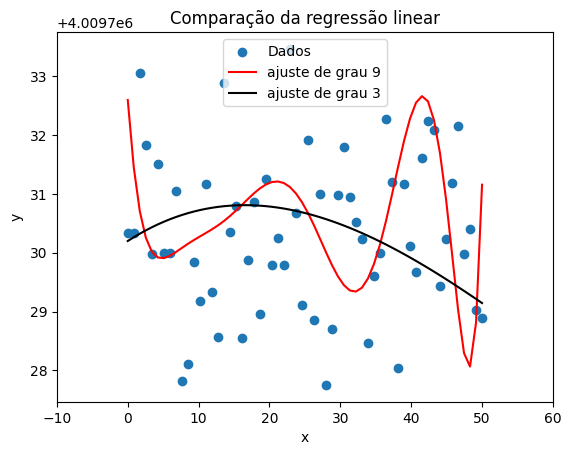

In [17]:
LR = LpProblem("RL", LpMinimize)

# Definindo as variáveis de regressão
a3 = LpVariable("a3", cat='Continuous')
a2 = LpVariable("a2", cat='Continuous')
a1 = LpVariable("a1", cat='Continuous')
a0 = LpVariable("a0", cat='Continuous')

# Variáveis auxiliares para conseguir linearizar o problema
Z = LpVariable.dicts("Z", range(len(x)), cat='Continuous')

# Adiciona as restrições para modelar o valor absoluto
for i in range(len(x)):
    LR += a3*x[i]**3 + a2*x[i]**2 + a1*x[i] + a0 - y[i] <= Z[i]
    LR += -(a3*x[i]**3 + a2*x[i]**2 + a1*x[i] + a0 - y[i]) <= Z[i]

# Função objetivo
M = LpVariable("M", cat='Continuous')
for i in range(len(x)):
    LR += Z[i] <= M
LR += M

LR.solve()

a3_m = LR.variablesDict()["a3"].value()
a2_m = LR.variablesDict()["a2"].value()
a1_m = LR.variablesDict()["a1"].value()
a0_m = LR.variablesDict()["a0"].value()
coef_2 = [a0_m, a1_m, a2_m, a3_m]

k = 10

# Inicializa o problema LR2 antes de adicionar restrições e objetivo
LR2 = LpProblem("RL2", LpMinimize)

# Definindo as variáveis de regressão
coef = LpVariable.dicts("a", range(k), cat='Continuous')

# Variáveis auxiliares para conseguir linearizar o problema
Z = LpVariable.dicts("Z", range(len(x)), cat='Continuous')

# Adiciona as restrições para modelar o valor absoluto
for i in range(len(x)):
    LR2 += lpSum(coef[j] * x[i]**j for j in range(k)) - y[i] <= Z[i]
    LR2 += -(lpSum(coef[j] * x[i]**j for j in range(k)) - y[i]) <= Z[i]

# Função objetivo
M = LpVariable("M", cat='Continuous')
for i in range(len(x)):
    LR2 += Z[i] <= M
LR2 += M

LR2.solve()

plt.scatter(x, y, label='Dados')
# Calculate the fitted polynomial using the solved coefficients
y_fit = sum(coef[j].value() * x**j for j in range(k))
plt.plot(x, y_fit, color='red', label='ajuste de grau 9')
plt.plot(x, a3.value()*x**3 + a2.value()*x**2 + a1.value()*x + a0.value(), color='black', label='ajuste de grau 3')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação da regressão linear')
plt.legend()
plt.xlim(-10,  60)
plt.show()


Aqui temos alguns pontos interessante:
- os ajustes de grau k se mostraram muito parecidos
- enquanto os de grau cúbico muito diferentes, somente por mudar o algoritmo.

Após algumas pesquisas externas, o algoritmo de somar os resíduos tem a vantagem de ter formula fechada, apesar de sofrer com os outliers. Por outro lado, ao minimar o máximo os outliers são garantidos não explodir pelo critério de minimizar a distancia máxima, mas pode fazer uma estatística ruim da média. Portanto, ambos tem seus benefícios e cabe a analise caso a caso.

## Questões à Escolha 1: Exercício 1 cap 9

Nesta questão temos uma mineradora com 10 possíveis locais de mineração com certas restrições e cada uma com um retorno específico. Queremos maximizar o retorno dado todos os valores. Mas, os valores de retorno de cada local não foram dados, então fiz um pequeno código que gerasse os valores aleatoriamente.

In [61]:
import numpy as np
np.random.seed(42) #Pode mudar os valores da seed como quiser

vetor = np.random.normal(loc=100, scale=20, size=10).round().astype(int)
# O primeiro valor é a média, o segundo é o erro padrão e o terceiro o tamanho. Os 2 primeiros podem ser mudados como queira.
print(vetor)

C1,C2,C3,C4,C5,C6,C7,C8,C9,C10 = vetor


[110  97 113 130  95  95 132 115  91 111]


E em seguida, o código em si da otimização.

In [62]:
FP = LpProblem("FP", LpMaximize)

lp = LpProblem("bond-problem",LpMaximize) #problema 3.b

S1 = LpVariable(name="S1", lowBound=0, upBound=1, cat="Integer")
S2 = LpVariable(name="S2", lowBound=0, upBound=1, cat="Integer")
S3 = LpVariable(name="S3", lowBound=0, upBound=1, cat="Integer")
S4 = LpVariable(name="S4", lowBound=0, upBound=1, cat="Integer")
S5 = LpVariable(name="S5", lowBound=0, upBound=1, cat="Integer")
S6 = LpVariable(name="S6", lowBound=0, upBound=1, cat="Integer")
S7 = LpVariable(name="S7", lowBound=0, upBound=1, cat="Integer")
S8 = LpVariable(name="S8", lowBound=0, upBound=1, cat="Integer")
S9 = LpVariable(name="S9", lowBound=0, upBound=1, cat="Integer")
S10 = LpVariable(name="S10", lowBound=0, upBound=1, cat="Integer")

lp += C1*S1 + C2*S2 + C3*S3 + C4*S4 + C5*S5 + C6*S6 + C7*S7 + C8*S8 + C9*S9 + C10*S10

#as restrições tinham modelos diferentes
lp += S1 + S7 + S8 <= 2  #i) explorar os locais 1 e 7 impedem de explorar o 8.
lp += S3 + S5 <= 1 #ii) ao explorar o local 3, não se pode explorar o 5.
lp += S4 + S5 <= 1 #ii) ao explorar o local 4, não se pode explorar o 5.
lp += S5 + S6 + S7 +S8 <= 2 #iii) dentre os locais 5, 6, 7 e 8, no máximo 2 podem ser explorados.

status = lp.solve()

to_explore = []
to_not_explore = []

for var in lp.variables():
    if var.value() == 1:
        to_explore.append(var.name)
        continue
    if var.value() == 0:
        to_not_explore.append(var.name)

print("Os locais a serem explorados são:", to_explore)
print("Os locais a não serem explorados são:", to_not_explore)
print("O valor máximo a receber é", lp.objective.value())

Os locais a serem explorados são: ['S1', 'S10', 'S2', 'S3', 'S4', 'S6', 'S7', 'S9']
Os locais a não serem explorados são: ['S5', 'S8']
O valor máximo a receber é 879.0


## Questões à Escolha 2: Exercício 2 cap 9

Nesta questão queremos um pacote de 10 cursos de 6 áreas que podem ser feitos em 5 universidade, e queremos achar o pacote com menor custo possível. Em cada curso devemos pagar uma taxa respectiva ao curso e por universidade associada(a matrícula da universidade é paga uma única vez independente do número de cursos escolhidas na mesma). E neste pacote devem ter pelo menos 1 curso de cada área.

Após assumir que cada universidade oferece 1 curso de cada área, precisamos obter os valores de matrículas das faculdades e dos cursos, então fiz um pequeno código para gera-los aleatoriamente. Caso queira mudar os parametros da gaussiana ou da seed do numpy basta altera-los na próxima célula de código.

In [63]:
np.random.seed(42) #Pode mudar os valores da seed como quiser

# primeiro para pegarmos as matriculas de cada faculdade
matriculas = np.random.normal(loc=20000, scale=2500, size=5).round().astype(int)
# O primeiro valor é a média, o segundo é o erro padrão e o terceiro o tamanho. Os 2 primeiros podem ser mudados como queira.
print(" os preços das matrículas ",matriculas)

#agora para o preço de cada curso, vou por o preço de cada curso como aleatório e cada faculdade tendo 1 curso de cada disciplina, ou seja, 30 disciplinas ao todo
cursos = np.random.normal(loc=500, scale=50, size=(5, 6)).round().astype(int)
print("os preços dos cursos ")
print(cursos) #Considere como C1 os cursos oferecidos pela faculdade 1. E os campos são referentes ao índice do curso, ou seja, o curso C1[0] e o curso C2[0] saõ do mesmo campo.


 os preços das matrículas  [21242 19654 21619 23808 19415]
os preços dos cursos 
[[488 579 538 477 527 477]
 [477 512 404 414 472 449]
 [516 455 429 573 489 503]
 [429 473 506 442 519 470]
 [485 470 593 499 447 541]]


E em seguida o código da otimização em si.

In [64]:
lp = LpProblem("College", LpMinimize) 

#definição das variáveis, optei por usar um vetor e uma matriz para aprender a como usa-las em pulp
M = LpVariable.dicts("M", range(5), lowBound=0, upBound=1,cat="Integer") 
C = LpVariable.dicts("C", (range(5), range(6)), lowBound=0,upBound=1, cat="Integer")

#função objetivo: o custo total
lp += lpSum(M[i]*matriculas[i] for i in range(5)) + lpSum(C[i][j]*cursos[i][j] for i in range(5) for j in range(6))

#restrição 1: deve pagar a matrícula de toda universidade que pelo menos 1 curso é selecionado
for i in range(5):
    for j in range(6):
        lp += C[i][j] <= M[i]  

#restrição 2: O pacote deve ter pelo menos 1 curso de cada área
for j in range(6):
    lp += lpSum(C[i][j] for i in range(5)) >= 1

#restrição 3: O pacote deve ter exatamente 10 cursos
lp += lpSum(C[i][j] for i in range(5) for j in range(6)) == 10

status = lp.solve()

print("os cursos a serem assinados são:")
for var in lp.variables():
    if var.value() > 0 and "C" in var.name:
        print(f"{var.name}")
print("as faculdades a serem contratadas são:")
for var in lp.variables():
    if var.value() > 0 and "M" in var.name:
        print(f"{var.name}")

print("O preço total a ser pago é:", lp.objective.value())

os cursos a serem assinados são:
C_1_0
C_1_1
C_1_2
C_1_3
C_1_4
C_1_5
C_4_0
C_4_1
C_4_3
C_4_4
as faculdades a serem contratadas são:
M_1
M_4
O preço total a ser pago é: 43698.0


# Questões á escolha 3: Exercício 2 cap 8

Um primeiro ponto importante é que nestas questões do capítulo 8 os dados já estão dados e fixos, então os códigos só contém a otimização das informações já estabelecidas.

Neste novo problema temos um aluguel de carros de 3 filiais para 4 região, cada filial a cada cidade tem um preço diferente, cada cidade tem uma demanda a cumprir e cada filial um número máximo de alugueis. Como todos os valores já estão definidos, partirei para a otimização.

In [65]:
precos = [[7,11,3,2],[1,6,0,1],[9,15,8,5]]
demanda = [2,3,5,7]
oferta = [6,1,10]

lp = LpProblem("rent_a_car", LpMinimize) 

#definição das variáveis, o elemento R[i][j] representa quantos carros da filial i vão para o destino j
R = LpVariable.dicts("R", (range(3), range(4)), lowBound=0, cat="Integer")

#função objetivo: o custo total
lp += lpSum(R[i][j]*precos[i][j] for i in range(3) for j in range(4))

#restrição 1: cada filial tem um limite de carros disponíveis
for i in range(3):
        lp += lpSum(R[i][j] for j in range(4)) <= oferta[i] 

#restrição 2: cada região deve receber a sua devida demanda de carros
for j in range(4):
        lp += lpSum(R[i][j] for i in range(3)) == demanda[j]

lp.solve()

print("O menor valor para o aluguel total é:",lp.objective.value())

O menor valor para o aluguel total é: 100.0


# Questão a escolha 4: exercício 4 cap 8

In [66]:
demanda = [300,200, 150, 500, 400]
oferta = [600, 500, 300, 400]
lucros = [[5.5,7,8.5,4.5,3],[6,6.5,9,3.5,2],[5,7,9.5,4,2.5],[6.5,5.5,8,5,3.5]]

lp = LpProblem("racquets", LpMaximize)

#definição das variáveis, o elemento R[i][j] representa quantas raquetes da loja i modelo j são comprados
R = LpVariable.dicts("R", (range(4), range(5)), lowBound=0, cat="Integer")

#função objetivo: o custo total
lp += lpSum(R[i][j]*lucros[i][j] for i in range(4) for j in range(5))

#restrição 1: cada filial tem um limite de raquetes disponíveis
for i in range(4):
        lp += lpSum(R[i][j] for j in range(5)) <= oferta[i]

#restrição 2: Devem ser compradas exatamente a demanda de cada modelo
for j in range(5):
        lp += lpSum(R[i][j] for i in range(4)) == demanda[j]

lp.solve()

print("O maior lucro possível é:", lp.objective.value())

O maior lucro possível é: 8275.0
